# performance vs astropy and lmfit

In [22]:
from astropy.modeling.models import Gaussian1D
from model import Model
import numpy as np
import timeit

def gaussian(x, mu, sigma, amp):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

x = np.linspace(0,10, 1000)

astropy_gaussian = Gaussian1D(mean=1, amplitude=1, stddev=1)

my_gaussian = Model.wrap(gaussian, grid_variables=['x'])


def astropy_bench():
    return astropy_gaussian(x)

def cosmosynth_bench():
    return my_gaussian(x)

def optimized_call():
    return gaussian(x, mu=1,sigma=1,amp=1)

time_astropy = timeit.timeit(astropy_bench, number=10_000)
time_cosmosynth = timeit.timeit(cosmosynth_bench, number=10_000)
time_optimized = timeit.timeit(optimized_call, number=10_000)


print(f"astropy call : {time_astropy:.6f} seconds")
print(f"my model call: {time_cosmosynth:.6f} seconds")
print(f"time fast evaluation: {time_optimized:.6f} seconds")


astropy call : 0.174095 seconds
my model call: 0.067165 seconds
time fast evaluation: 0.056938 seconds


Numero di punti: 1, funz1: 0.1329s, funz2: 0.0317s, funz3: 0.0231s
Numero di punti: 10, funz1: 0.1360s, funz2: 0.0319s, funz3: 0.0239s
Numero di punti: 50, funz1: 0.1379s, funz2: 0.0332s, funz3: 0.0252s
Numero di punti: 100, funz1: 0.1390s, funz2: 0.0347s, funz3: 0.0271s
Numero di punti: 200, funz1: 0.1428s, funz2: 0.0399s, funz3: 0.0320s
Numero di punti: 300, funz1: 0.1488s, funz2: 0.0434s, funz3: 0.0359s
Numero di punti: 500, funz1: 0.1553s, funz2: 0.0497s, funz3: 0.0422s
Numero di punti: 1000, funz1: 0.1745s, funz2: 0.0687s, funz3: 0.0600s
Numero di punti: 1500, funz1: 0.1871s, funz2: 0.0837s, funz3: 0.0759s
Numero di punti: 2000, funz1: 0.2020s, funz2: 0.1010s, funz3: 0.0932s


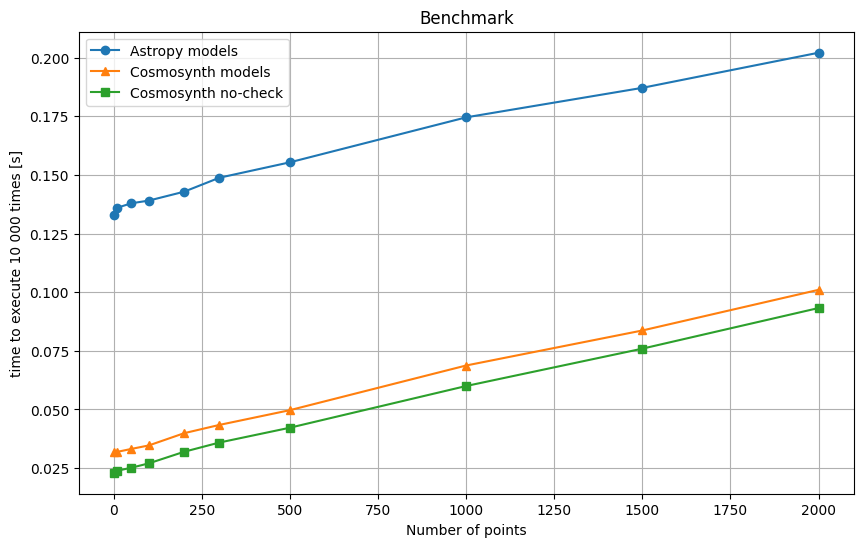

In [19]:
import time
import numpy as np
import matplotlib.pyplot as plt


# Lista dei numeri di punti da testare
punti_list = [1, 10, 50, 100, 200, 300, 500, 1000, 1500, 2000]

# Liste per salvare i tempi di esecuzione delle tre funzioni
tempi1 = []
tempi2 = []
tempi3 = []

# Numero di ripetizioni per stabilizzare la misura
ripetizioni = 10_000

for n in punti_list:
    # Creiamo un array di n punti, ad esempio da -5 a 5
    x = np.linspace(-5, 5, n)

    # --- Benchmark Funzione 1 ---
    start_time = time.time()
    for _ in range(ripetizioni):
        _ = astropy_bench()
    tempo1 = time.time() - start_time
    tempi1.append(tempo1)

    # --- Benchmark Funzione 2 ---
    start_time = time.time()
    for _ in range(ripetizioni):
        _ = cosmosynth_bench()
    tempo2 = time.time() - start_time
    tempi2.append(tempo2)

    # --- Benchmark Funzione 3 ---
    start_time = time.time()
    for _ in range(ripetizioni):
        _ = optimized_call()
    tempo3 = time.time() - start_time
    tempi3.append(tempo3)

    print(
        f"Numero di punti: {n}, "
        f"funz1: {tempo1:.4f}s, "
        f"funz2: {tempo2:.4f}s, "
        f"funz3: {tempo3:.4f}s"
    )

# Tracciamo i risultati su un unico grafico
plt.figure(figsize=(10, 6))
plt.plot(punti_list, tempi1, marker="o", label="Astropy models")
plt.plot(punti_list, tempi2, marker="^", label="Cosmosynth models")
plt.plot(punti_list, tempi3, marker="s", label="Cosmosynth no-check")

plt.title("Benchmark")
plt.xlabel("Number of points")
plt.ylabel("time to execute 10 000 times [s]")
plt.grid(True)
plt.legend()
plt.show()


In [7]:
from model import Model
import numpy as np
from priors import UniformPrior

# define my function
def gaussian(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


# create the model
my_model = Model.wrap(
    func = gaussian,
    params = ['mu', 'sigma'],
    #grid_variables = ['x']
    param_option = {
        'mu':{
            'value':10,
            'description':'Gaussian mu0',
            'prior': UniformPrior(-20, 20),
            'frozen': False
        },
        'sigma':{
            'value':2.5,
            'frozen':True,                        
        }
    },
    name = 'My Gaussian Model'
)

print(my_model)

MODEL NAME: My Gaussian Model
FREE PARAMS: 1
GRID VARIABLES: ['x']
N-DIM: 1
----------------------------------------------------------------------------------------------------
  INDEX  NAME      VALUE  FROZEN    PRIOR               DESCR
      0  mu         10    No        Uniform(-20, 20)    Gaussian mu0
      1  sigma       2.5  Yes       Uniform(-inf, inf)


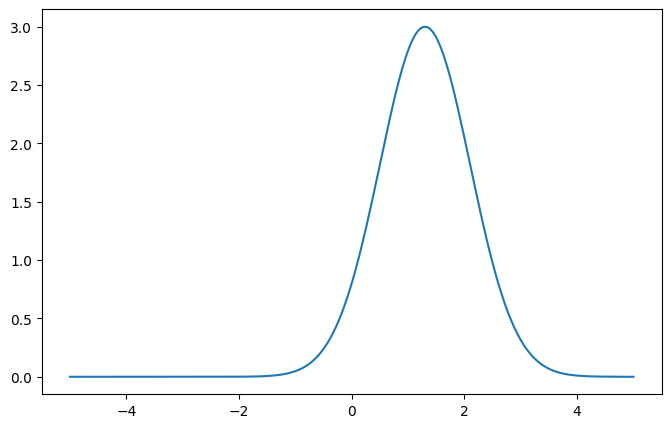

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
from astropy.modeling import models


gaussian = models.Gaussian1D()


np.random.seed(0)
x = np.linspace(-5.0, 5.0, 200)
y = 3 * np.exp(-0.5 * (x - 1.3) ** 2 / 0.8**2)
#y += np.random.normal(0.0, 0.2, x.shape)
yerr = 0.2

plt.figure(figsize=(8, 5))
plt.plot(x, y)

In [4]:
print(gaussian)

Model: Gaussian1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
    amplitude mean stddev
    --------- ---- ------
          1.0  0.0    1.0


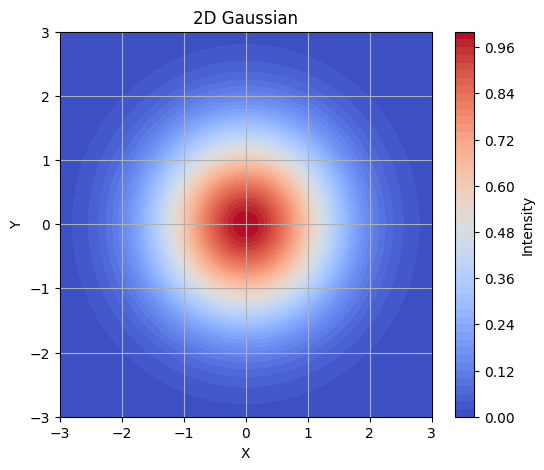

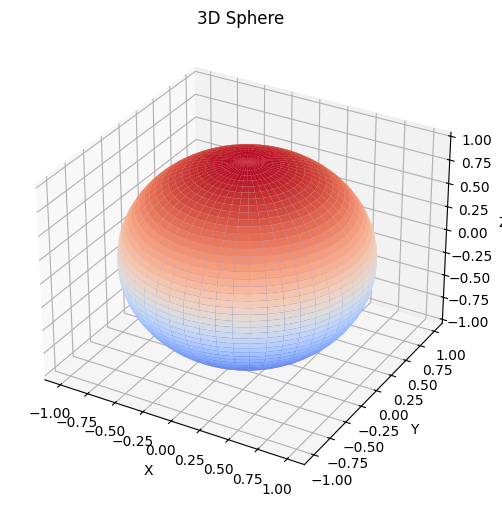

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
x, y = np.meshgrid(x, y)


# Gaussian 2D function
def gaussian_2d(x, y, x0, y0, sigma_x, sigma_y):
    return np.exp(
        -((x - x0) ** 2 / (2 * sigma_x**2) + \
            (y - y0) ** 2 / (2 * sigma_y**2))
    )
    
model_2d = Model.wrap(gaussian_2d, 
                      grid_variables=['x', 'y'])

z = model_2d(x, y, x0=0, y0=0, sigma_x=1, sigma_y=1)

# Plot the Gaussian
plt.figure(figsize=(6, 5))
plt.contourf(x, y, z, levels=50, cmap="coolwarm")
plt.colorbar(label="Intensity")
plt.title("2D Gaussian")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

theta = np.linspace(0, np.pi, 50)  # Polar angle
phi = np.linspace(0, 2 * np.pi, 50)  # Azimuthal angle
theta, phi = np.meshgrid(theta, phi)
r = 1

# Sphere function
def sphere(theta, phi, r):
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return x, y, z

sphere_model = Model.wrap(sphere,
                          params=['r'],
                          noutputs = 3)

x, y, z = sphere_model(theta, phi, r=1)

# Plot the sphere
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(x, y, z, cmap="coolwarm", edgecolor="none")
ax.set_title("3D Sphere")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


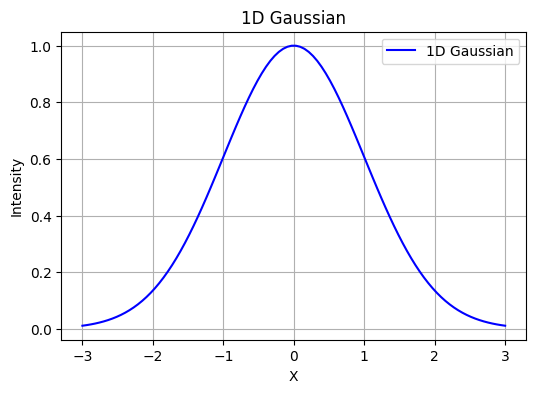

In [21]:
x_1d = np.linspace(-3, 3, 100)

# Gaussian 1D function
def gaussian_1d(x, x0, sigma):
    return np.exp(-((x - x0) ** 2) / (2 * sigma**2))

model_1d = Model.wrap(gaussian_1d,
                      grid_variables=['x'])

z_1d = model_1d(x_1d, x0=0, sigma=1)


# Plot the 1D Gaussian
plt.figure(figsize=(6, 4))
plt.plot(x_1d, z_1d, label="1D Gaussian", color="blue")
plt.title("1D Gaussian")
plt.xlabel("X")
plt.ylabel("Intensity")
plt.grid(True)
plt.legend()
plt.show()
